# Serverless RL on Kimi K3: human-sounding social copy

A single-turn, no-tools counterpart to the text-to-SQL tool-calling notebook. Same serverless loop -- **rollout -> reward -> weight update** -- but the reward comes from a **real external API**: [GPTZero](https://gptzero.me)'s AI-text detector. We LoRA-tune **Kimi K3** (2.8T MoE) to write tweets / LinkedIn posts that read as more human, using the detector's `human` probability as the learning signal.

The loop, one step (repeats every optimizer step):

```
save_weights_for_sampler        (snapshot current adapter)
        |
        v
create_sampling_client          (sampler bound to that snapshot)
        |
        v
write one post                  (single-turn rollout)
        |
        v
GPTZero human score x guardrails   (reward)
        |
        v
group-relative advantages (GRPO)
        |
        v
importance-sampling datums
        |
        v
forward_backward  ->  optim_step   (update the adapter)
        |
        └──────────────► back to top (next step)
```

## Why this design

- **Single-turn** (one generation per episode) -- K3 is a large MoE, so avoiding multi-turn keeps each step cheap.
- **The reward model is an HTTP API, not an LLM judge.** GPTZero returns `class_probabilities.human`; that scalar is the reward.
- **Reward hacking is the lesson.** Optimizing the detector score alone makes the model exploit the detector (degenerate text that scores "human" but reads badly). We gate the reward with programmatic quality checks (length, on-topic, non-degenerate) so RL improves *writing*, not just *detector-gaming*. Try turning the gate off to watch it collapse.

> Defaults tuned for a visible learning curve (20 steps, 8 samples/brief, LR `2.5e-5`). Track **mean human score** and **high-human rate** (samples >= `HUMAN_GOAL`). This is an educational demo of RL against an external reward signal. AI detectors are noisy and gameable -- treat the `human` score as a proxy metric, not ground truth, and mind the detector's API terms.

## 1. Setup

```bash
pip install --pre "fireworks-ai[training]" transformers httpx python-dotenv matplotlib
export FIREWORKS_API_KEY=fw_...
export GPT_ZERO_API_KEY=...     # from gptzero.me (or put both in a .env at the repo root)
```

Kimi K3 ships its chat template in Python (no Jinja), so we register the cookbook's K3 renderer from `training/renderer/kimi_k3.py`. Launch this notebook from anywhere in the repo.

In [1]:
import asyncio
import json
import math
import os
import random
import sys
import threading
from pathlib import Path

import tinker
from fireworks.training.sdk import FiretitanServiceClient
from tinker_cookbook.renderers import get_renderer, get_text_content
from transformers import AutoTokenizer

try:
    from dotenv import load_dotenv

    load_dotenv()  # picks up FIREWORKS_API_KEY / GPT_ZERO_API_KEY from a .env
except ImportError:
    pass

# Register the cookbook K3 renderer (Kimi K3 has no Jinja template; it ships one in code).
_HERE = Path.cwd()
_REPO_ROOT = next(
    (p for p in [_HERE, *_HERE.parents] if (p / "training" / "renderer" / "kimi_k3.py").exists()),
    None,
)
assert _REPO_ROOT is not None, "could not locate training/renderer/kimi_k3.py -- run inside the cookbook repo"
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))
import training.renderer.kimi_k3  # noqa: F401  registers "kimi_k3" / "kimi_k3_disable_thinking"

RUN_DIR = _HERE if (_HERE / "serverless_humansound_rl.ipynb").exists() else _REPO_ROOT

API_KEY = os.environ.get("FIREWORKS_API_KEY", "")
GPTZERO_API_KEY = os.environ.get("GPT_ZERO_API_KEY", "")
assert API_KEY, "set FIREWORKS_API_KEY"
assert GPTZERO_API_KEY, "set GPT_ZERO_API_KEY (the reward comes from GPTZero)"

# --- what to train -----------------------------------------------------------
BASE_MODEL = "accounts/fireworks/models/kimi-k3"
TOKENIZER = "moonshotai/Kimi-K3"
RENDERER = "kimi_k3_disable_thinking"  # no long CoT: we want the post, cheaply
LORA_RANK = 64

# --- RL loop shape (aligned with countdown K3 run) -----------------------------
STEPS = 20
PROMPT_GROUPS_PER_STEP = 8
GROUP_SIZE = 8               # posts sampled per brief (GRPO group)
MAX_SAMPLE_TOKENS = 16_000
TEMPERATURE = 1.0
LEARNING_RATE = 2e-5       # countdown K3 default; lower to 1e-5 if GPTZero signal gets spikey
MAX_SEQ_LEN = 65536
PROMPT_CONCURRENCY = 4       # sample() calls in flight
SAMPLING_TIMEOUT_S = 1800.0

# --- reward ------------------------------------------------------------------
USE_GUARDRAILS = True       # True = quality gate x detector; False = pure detector (reward-hack demo)
HUMAN_GOAL = 0.7             # threshold for high-human rate (like solve rate in Countdown)
GPTZERO_URL = "https://api.gptzero.me/v2/predict/text"
print("config ready")

/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


config ready


## 2. Connect to the serverless session

One `FiretitanServiceClient` on `/training/v1/serverless` gives both the LoRA training client and (later) samplers. K3's tokenizer needs `trust_remote_code=True`.

In [2]:
def _serverless_base_url(base_url: str) -> str:
    root = base_url.rstrip("/")
    if root.endswith("/training/v1/serverless"):
        return root
    if root.endswith("/training/v1"):
        return f"{root}/serverless"
    return f"{root}/training/v1/serverless"


api_base = os.environ.get("FIREWORKS_BASE_URL", "https://api.fireworks.ai")
service = FiretitanServiceClient(api_key=API_KEY, base_url=_serverless_base_url(api_base))
training_client = service.create_lora_training_client(base_model=BASE_MODEL, rank=LORA_RANK)

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER, trust_remote_code=True)
renderer = get_renderer(RENDERER, tokenizer)

print(
    f"session={getattr(service, 'training_session_id', None)} "
    f"run={getattr(training_client, 'run_id', None)}\n"
    f"base_model={BASE_MODEL} renderer={RENDERER} rank={LORA_RANK}"
)

session=ts-eebb3d7ba41745919ee977603f36989a run=run-fdfa8b34e42d43e8a4d1e1cb9d3cfa08
base_model=accounts/fireworks/models/kimi-k3 renderer=kimi_k3_disable_thinking rank=64


Session heartbeat failed for 121.39859758294187 seconds for session ts-eebb3d7ba41745919ee977603f36989a. Last exception: InternalServerError: Error code: 503 - {'error': {'message': 'session_heartbeat: trainer route not found', 'param': None, 'code': 'SERVICE_UNAVAILABLE', 'type': 'error'}, 'request_id': 'e071e8a9-f8e1-49f4-a151-8eac7e2fb8f4'}.
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 131.4271427920321 seconds for session ts-eebb3d7ba41745919ee977603f36989a. Last exception: InternalServerError: Error code: 503 - {'error': {'message': 'session_heartbeat: trainer route not found', 'param': None, 'code': 'SERVICE_UNAVAILABLE', 'type': 'error'}, 'request_id': '5dd8d97f-4d52-4080-b149-b8ffce25c451'}.
Your connection may be unreliable or Tinker is down. If this persists, the session will be terminated.
Session heartbeat failed for 141.44818916695658 seconds for session ts-eebb3d7ba41745919ee977603f3698

## 3. Briefs from live Fireworks blog posts (temporal split)

Instead of synthetic topics, we scrape the Fireworks blog list from `sitemap.xml` (one request) and turn each post into a **brief** = platform (`tweet` / `linkedin`) + topic (from the post slug) + keywords (for the on-topic guardrail). We split by date: **older posts -> train, newest posts -> held-out test**, so the eval measures generalization to topics the model didn't train on.

In [3]:
import re

import httpx

SITEMAP_URL = "https://fireworks.ai/sitemap.xml"
PLATFORMS = ["tweet", "linkedin"]
HOLDOUT_NEWEST_POSTS = 20  # newest N blog posts -> held-out test; the rest -> train
_STOP = {"the", "and", "for", "with", "your", "our", "you", "are", "from", "into",
         "how", "why", "now", "day", "live", "new", "using", "run", "fireworks", "blog"}


def _slug_to_topic(slug: str) -> str:
    return slug.replace("-", " ").strip()


def _keywords(slug: str) -> list[str]:
    return [w for w in slug.split("-") if len(w) > 3 and w not in _STOP][:4]


# One request: pull the blog list + dates from the sitemap.
_xml = httpx.get(SITEMAP_URL, timeout=30.0)
_xml.raise_for_status()
_entries = re.findall(r"<loc>(.*?)</loc>\s*<lastmod>(.*?)</lastmod>", _xml.text, re.DOTALL)
_posts_by_slug: dict[str, dict] = {}
for _url, _date in _entries:
    _url = _url.strip()
    if "/blog/" not in _url:
        continue
    slug = _url.rstrip("/").split("/blog/")[-1]
    if not slug or "/" in slug:  # skip the index and nested paths
        continue
    _posts_by_slug[slug] = {"slug": slug, "url": _url, "date": _date.strip(),
                            "topic": _slug_to_topic(slug), "keywords": _keywords(slug)}

posts = sorted(_posts_by_slug.values(), key=lambda p: p["date"])
assert len(posts) > 40, f"only scraped {len(posts)} blog posts -- sitemap format may have changed"
older_posts = posts[:-HOLDOUT_NEWEST_POSTS]
newer_posts = posts[-HOLDOUT_NEWEST_POSTS:]


def _briefs(post_list: list[dict]) -> list[dict]:
    out = []
    for p in post_list:
        kws = p["keywords"] or [p["slug"].split("-")[0]]
        for pl in PLATFORMS:
            out.append({"platform": pl, "topic": p["topic"], "keywords": kws,
                        "id": f"{pl}:{p['slug']}", "url": p["url"], "date": p["date"]})
    return out


random.seed(7)
train_briefs = _briefs(older_posts)
holdout_briefs = _briefs(newer_posts)
random.shuffle(train_briefs)
random.shuffle(holdout_briefs)
assert train_briefs and holdout_briefs
print(
    f"scraped {len(posts)} blog posts | "
    f"train: {len(train_briefs)} briefs (<= {older_posts[-1]['date'][:10]}) | "
    f"holdout: {len(holdout_briefs)} briefs (>= {newer_posts[0]['date'][:10]})"
)
print("sample topics:", [p["topic"] for p in newer_posts[-3:]])


def brief_prompt(brief: dict) -> str:
    if brief["platform"] == "tweet":
        constraint = "Write a single tweet (max 280 characters)."
    else:
        constraint = "Write a single LinkedIn post (roughly 60-200 words, a few short paragraphs)."
    return (
        f"{constraint} Promote this Fireworks blog post: \"{brief['topic']}\".\n"
        "Return only the post text -- no preamble, no hashtag dumps, no quotes around it."
    )


SYSTEM_PROMPT = (
    "You are a sharp, natural social-media writer. You write posts that sound like a real "
    "person -- specific, varied in rhythm, no filler, no cliches. Never mention being an AI."
)

scraped 163 blog posts | train: 286 briefs (<= 2026-06-19) | holdout: 40 briefs (>= 2026-06-22)
sample topics: ['fireworks nexus', 'kernel optimization for minimax m3 on nvidia blackwell', 'kimik3 on fireworks']


## 4. Reward: GPTZero human score x guardrails

`human_score(text)` calls GPTZero and returns `class_probabilities.human` in `[0, 1]` -- the learning signal. On its own, RL will exploit the detector, so we multiply by a **validity gate** of programmatic checks (length for the platform, on-topic via keywords, non-degenerate text). Set `USE_GUARDRAILS = False` in the config to watch the reward-hacking failure mode.

In [4]:
import httpx


async def human_score(client: httpx.AsyncClient, text: str) -> float:
    """GPTZero P(human) for `text`, in [0, 1]. Returns 0.0 on empty text or API error."""
    if not text or not text.strip():
        return 0.0
    try:
        resp = await client.post(
            GPTZERO_URL,
            headers={"x-api-key": GPTZERO_API_KEY, "Content-Type": "application/json"},
            json={"document": text},
            timeout=60.0,
        )
        resp.raise_for_status()
        data = resp.json()
        doc = data["documents"][0]
        return float(doc["class_probabilities"]["human"])
    except Exception:
        return 0.0  # network/rate-limit hiccup -> no signal this episode


def _word_count(text: str) -> int:
    return len(text.split())


def validity_gate(text: str, brief: dict) -> float:
    """Programmatic quality checks. Returns 1.0 if the post is a usable answer, else 0.0.

    This is what stops RL from collapsing to detector-gaming gibberish. Flip
    USE_GUARDRAILS off in the config to see the pure-detector reward hack.
    """
    if not USE_GUARDRAILS:
        return 1.0
    body = text.strip()
    if not body:
        return 0.0
    # platform length limits
    if brief["platform"] == "tweet":
        if len(body) > 280 or _word_count(body) < 5:
            return 0.0
    else:  # linkedin
        if not (40 <= _word_count(body) <= 300):
            return 0.0
    # on-topic: mention at least one topic keyword
    low = body.lower()
    if not any(kw.lower() in low for kw in brief["keywords"]):
        return 0.0
    # non-degenerate: enough lexical variety (kills repetition/gibberish)
    words = [w.lower() for w in body.split()]
    if len(set(words)) / max(len(words), 1) < 0.45:
        return 0.0
    return 1.0


async def score_text(client: httpx.AsyncClient, text: str, brief: dict) -> float:
    gate = validity_gate(text, brief)
    if gate == 0.0:
        return 0.0
    return gate * await human_score(client, text)
print("reward defined")

reward defined


## 5. RL primitives

Group-relative advantages (GRPO) and the shifted next-token training datum -- identical to the tool-calling notebook. Since this task is single-turn, each episode contributes exactly one datum.

In [5]:
def group_relative_advantages(rewards, eps=1e-8):
    if len(rewards) <= 1:
        return [0.0 for _ in rewards]
    mean = sum(rewards) / len(rewards)
    var = sum((r - mean) ** 2 for r in rewards) / (len(rewards) - 1)
    std = math.sqrt(var)
    if std < eps:
        std = 1.0
    return [(r - mean) / (std + eps) for r in rewards]


def make_datum(prompt, tokens, logprobs, advantage):
    """One generation -> one importance-sampling datum (shifted next-token layout)."""
    response_start = prompt.length - 1
    model_input = prompt.append(tinker.EncodedTextChunk(tokens=tokens[:-1]))
    return tinker.Datum(
        model_input=model_input,
        loss_fn_inputs={
            "target_tokens": [0] * response_start + tokens,
            "logprobs": [0.0] * response_start + logprobs,
            "advantages": [0.0] * response_start + [advantage] * (model_input.length - response_start),
        },
    )

## 6. Rollout + scoring

`run_episode` renders the brief, samples one post, and keeps the sampled tokens + logprobs (for the datum) and the decoded text (for the reward). `score_all` scores a batch of posts concurrently against GPTZero on a shared background event loop.

In [6]:
class _BackgroundLoop:
    """One long-lived event loop in a daemon thread for run_coro (keeps httpx clients valid)."""

    def __init__(self):
        self.loop = asyncio.new_event_loop()
        threading.Thread(target=self.loop.run_forever, daemon=True).start()

    def run(self, coro):
        return asyncio.run_coroutine_threadsafe(coro, self.loop).result()


_BG_LOOP = _BackgroundLoop()


def run_coro(coro):
    return _BG_LOOP.run(coro)


def _extract_text(tokens) -> str:
    msg, _ = renderer.parse_response(tokens)
    content = msg.get("content", "")
    if isinstance(content, str):
        return content.strip()
    try:
        return get_text_content(msg).strip()
    except Exception:
        return "".join(p.get("text", "") for p in content if p.get("type") == "text").strip()


def high_human_rate(rewards, threshold=HUMAN_GOAL):
    """Fraction of samples with GPTZero human score >= threshold."""
    if not rewards:
        return 0.0
    return sum(1 for r in rewards if r >= threshold) / len(rewards)


def sample_group(sampler, brief):
    """Sample GROUP_SIZE posts for one brief."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": brief_prompt(brief)},
    ]
    prompt = renderer.build_generation_prompt(messages)
    if prompt.length + MAX_SAMPLE_TOKENS > MAX_SEQ_LEN:
        return []
    params = tinker.SamplingParams(
        max_tokens=MAX_SAMPLE_TOKENS,
        temperature=TEMPERATURE,
        stop=renderer.get_stop_sequences(),
    )
    fut = sampler.sample(prompt=prompt, num_samples=GROUP_SIZE, sampling_params=params)
    result = fut.result(timeout=SAMPLING_TIMEOUT_S) if hasattr(fut, "result") else fut

    samples = []
    for seq in getattr(result, "sequences", []) or []:
        tokens = list(getattr(seq, "tokens", []) or [])
        logprobs = getattr(seq, "logprobs", None)
        if not tokens or logprobs is None or len(logprobs) != len(tokens):
            continue
        samples.append({
            "prompt": prompt,
            "tokens": tokens,
            "logprobs": [float(x) for x in logprobs],
            "text": _extract_text(tokens),
            "brief": brief,
        })
    return samples


def rollout_batch(sampler, brief_list):
    """GROUP_SIZE samples per brief, PROMPT_CONCURRENCY sample() calls in flight."""
    from concurrent.futures import ThreadPoolExecutor

    chunk = max(1, PROMPT_CONCURRENCY)
    groups = []
    with ThreadPoolExecutor(max_workers=chunk) as ex:
        for start in range(0, len(brief_list), chunk):
            slice_briefs = brief_list[start : start + chunk]
            for samples in ex.map(lambda b: sample_group(sampler, b), slice_briefs):
                groups.append(samples)
    return groups


async def _score_all(episodes):
    async with httpx.AsyncClient() as client:
        return await asyncio.gather(
            *[score_text(client, ep["text"], ep["brief"]) for ep in episodes]
        )


def score_all(episodes):
    return run_coro(_score_all(episodes))


print("rollout + scoring defined")

rollout + scoring defined


## 7. The RL loop

Each step: snapshot → sample `GROUP_SIZE` posts per brief → GPTZero score → GRPO → update.

We track **mean human score** (all samples) and **high-human rate** (fraction >= `HUMAN_GOAL`) — the latter is the Countdown-style "solve rate" for this task. Fixed holdout eval every `EVAL_EVERY` steps; publish the best-on-holdout checkpoint by mean score.

In [7]:
EVAL_EVERY = 2
eval_track_briefs = holdout_briefs[:12]

adam = tinker.AdamParams(learning_rate=LEARNING_RATE, beta1=0.9, beta2=0.95, eps=1e-8, weight_decay=0.0)
history, high_history = [], []
eval_history, eval_high_history, eval_steps = [], [], []
cursor = 0
base_snapshot = None
best_eval, best_snapshot, best_step = -1.0, None, -1
best_high, best_high_snapshot, best_high_step = -1.0, None, -1

for step in range(STEPS):
    snapshot = training_client.save_weights_for_sampler(f"humansound-{step:04d}").result().path
    if step == 0:
        base_snapshot = snapshot
    sampler = service.create_sampling_client(model_path=snapshot, tokenizer=tokenizer)

    batch = [train_briefs[(cursor + i) % len(train_briefs)] for i in range(PROMPT_GROUPS_PER_STEP)]
    cursor += PROMPT_GROUPS_PER_STEP

    do_eval = (step % EVAL_EVERY == 0) or (step == STEPS - 1)
    try:
        train_groups = rollout_batch(sampler, batch)
        eval_groups = rollout_batch(sampler, eval_track_briefs) if do_eval else []
    finally:
        sampler.close()

    datums, raw_rewards, kept_groups = [], [], 0
    for samples in train_groups:
        rewards = score_all(samples) if samples else []
        raw_rewards.extend(rewards)
        if not rewards or len(set(round(r, 4) for r in rewards)) <= 1:
            continue
        kept_groups += 1
        for sample, adv in zip(samples, group_relative_advantages(rewards)):
            d = make_datum(sample["prompt"], sample["tokens"], sample["logprobs"], adv)
            if d.model_input.length <= MAX_SEQ_LEN:
                datums.append(d)

    if datums:
        training_client.forward_backward(datums, "importance_sampling").result()
        training_client.optim_step(adam).result()

    mean_reward = sum(raw_rewards) / len(raw_rewards) if raw_rewards else 0.0
    train_high = high_human_rate(raw_rewards)
    history.append(mean_reward)
    high_history.append(train_high)

    eval_mean = eval_high = None
    if eval_groups:
        eval_rewards = []
        for samples in eval_groups:
            eval_rewards.extend(score_all(samples) if samples else [])
        eval_mean = sum(eval_rewards) / len(eval_rewards) if eval_rewards else 0.0
        eval_high = high_human_rate(eval_rewards)
        eval_history.append(eval_mean)
        eval_high_history.append(eval_high)
        eval_steps.append(step)
        if eval_mean > best_eval:
            best_eval, best_snapshot, best_step = eval_mean, snapshot, step
        if eval_high > best_high:
            best_high, best_high_snapshot, best_high_step = eval_high, snapshot, step

    print(
        f"step {step:02d} train={mean_reward:.3f} high={train_high:.1%} "
        f"eval={'n/a' if eval_mean is None else f'{eval_mean:.3f}'} "
        f"eval_high={'n/a' if eval_high is None else f'{eval_high:.1%}'} "
        f"kept_groups={kept_groups}/{len(batch)} datums={len(datums)}"
    )

DeploymentSampler request 566d563ad310482c8984d5480c0b2d03: Transient HTTP 503 (attempt 1/7); retrying after 1.0s.
DeploymentSampler request e3a442ce31bc4722b0ca93f6e50e09ec: Transient HTTP 503 (attempt 1/7); retrying after 2.6s.
DeploymentSampler request 3918fc2255214a02a7b4e4307c480459: Transient HTTP 503 (attempt 1/7); retrying after 2.5s.
DeploymentSampler request b50a01dbd040473e89af16a58c1cdaa8: Transient HTTP 503 (attempt 1/7); retrying after 1.2s.
DeploymentSampler request f49afbb02e8d4b4f993d49b3c5eeed44: Transient HTTP 503 (attempt 1/7); retrying after 2.5s.
DeploymentSampler request 46b3570b6f394d28813089549ed96c65: Transient HTTP 503 (attempt 1/7); retrying after 1.3s.
DeploymentSampler request f16b16238ddb45698333dc1e7bda2ebc: Transient HTTP 503 (attempt 1/7); retrying after 3.0s.
DeploymentSampler request 678360e4999f4f2f9402970ccd0526f0: Transient HTTP 503 (attempt 1/7); retrying after 1.4s.
DeploymentSampler request 83680b59df1143a6883b591d0610b16e: Transient HTTP 503 (

step 00 train=0.127 high=14.1% eval=0.045 eval_high=4.2% kept_groups=2/8 datums=16


DeploymentSampler request 48b13640ae434afa9893df488e0442e1: Transient HTTP 503 (attempt 1/7); retrying after 1.5s.
DeploymentSampler request 574434a965454ae985093edc2a26ba79: Transient HTTP 503 (attempt 1/7); retrying after 1.3s.


step 01 train=0.056 high=4.7% eval=n/a eval_high=n/a kept_groups=3/8 datums=24


DeploymentSampler request 7e47c14dec90440f848b5ea178dedc0e: Transient HTTP 503 (attempt 1/7); retrying after 1.9s.
DeploymentSampler request 8fa5d31a242f49bcb65f965cd56d512b: Transient HTTP 503 (attempt 1/7); retrying after 2.5s.
DeploymentSampler request 067343b1cc42478fa9931d349cde48b8: Transient HTTP 503 (attempt 1/7); retrying after 1.2s.
DeploymentSampler request d94b9d75d4cf4a7894d9e176d6e17319: Transient HTTP 503 (attempt 1/7); retrying after 2.8s.
DeploymentSampler request 43e31f16a01847cc91510c3f4a6c8396: Transient HTTP 503 (attempt 1/7); retrying after 1.3s.
DeploymentSampler request 879e8869e428448c93935ff09bd7e65b: Transient HTTP 503 (attempt 1/7); retrying after 2.3s.


...

step 17 train=0.160 high=15.6% eval=n/a eval_high=n/a kept_groups=3/8 datums=24


DeploymentSampler request 14a3a5c6be084119b42caf1eeba9ae06: Transient HTTP 503 (attempt 1/7); retrying after 1.3s.
DeploymentSampler request 067a3ec061a143e596fc2d6caf39bd8f: Transient HTTP 503 (attempt 1/7); retrying after 2.6s.
DeploymentSampler request 5e11e2960d584517a3746dcf5ac14df1: Transient HTTP 503 (attempt 1/7); retrying after 2.4s.
DeploymentSampler request e4e28562fa3b4d13aa90db391115a195: Transient HTTP 503 (attempt 1/7); retrying after 2.0s.
DeploymentSampler request c97a165788194607a1d0d055a3178c64: Transient HTTP 503 (attempt 1/7); retrying after 1.9s.
DeploymentSampler request c0818f90d106495084c0d1a7ca78d159: Transient HTTP 503 (attempt 1/7); retrying after 2.4s.
DeploymentSampler request 397223bcee0f43709e87444ad2a91086: Transient HTTP 503 (attempt 1/7); retrying after 2.0s.
DeploymentSampler request 67311bcf18234a2fa0b851fcab69df17: Transient HTTP 503 (attempt 1/7); retrying after 2.8s.
DeploymentSampler request a9d2dbdf7e9b4c5ba723052f5d88fbf2: Transient HTTP 503 (

step 18 train=0.292 high=26.6% eval=0.160 eval_high=13.5% kept_groups=5/8 datums=40


DeploymentSampler request 99a0796e6ac84c0bb96c6b1ef3116237: Transient HTTP 503 (attempt 1/7); retrying after 2.4s.
DeploymentSampler request 0eec996cd2ee4c689b1dc289af2b6ab8: Transient HTTP 503 (attempt 1/7); retrying after 2.6s.
DeploymentSampler request 746bc1eeeab54abd9d615de00ad00b67: Transient HTTP 503 (attempt 1/7); retrying after 2.4s.
DeploymentSampler request bedc6b2cac814615b22d90dd5df4acdd: Transient HTTP 503 (attempt 1/7); retrying after 2.9s.
DeploymentSampler request 00c4968d7deb48d6882d696ad827e9bf: Transient HTTP 503 (attempt 1/7); retrying after 2.3s.
DeploymentSampler request 4933829e2bea47bd8920bf3758c5619b: Transient HTTP 503 (attempt 1/7); retrying after 1.2s.
DeploymentSampler request 1d41f2128b16418a8483ff3db84699a6: Transient HTTP 503 (attempt 1/7); retrying after 1.1s.


step 19 train=0.102 high=9.4% eval=0.170 eval_high=16.7% kept_groups=5/8 datums=40


## 8. Reward curve + save the adapter

**Headline:** held-out high-human rate (>= `HUMAN_GOAL`). **Context:** mean GPTZero score (partial/noisy).

DeploymentSampler request 08f3be2a55354f0886556f4bb741f60f: Transient HTTP 503 (attempt 1/7); retrying after 2.3s.
DeploymentSampler request 29bcedac92cd4e06ba8c4a6b9d483717: Transient HTTP 503 (attempt 1/7); retrying after 2.9s.


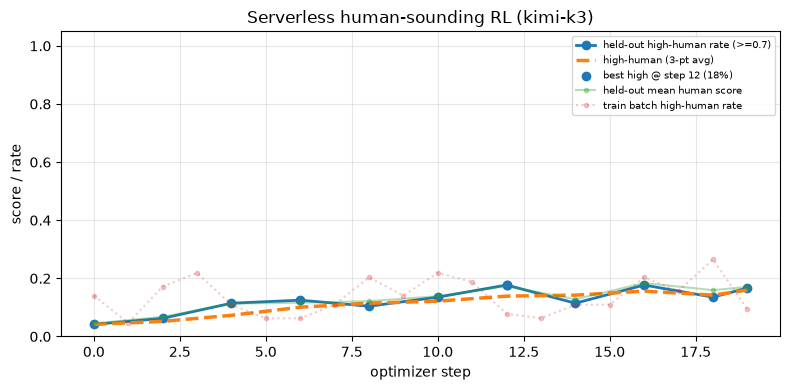

final adapter snapshot: pyroworks/run-fdfa8b34e42d43e8a4d1e1cb9d3cfa08/humansound-final-3cc4d157
best by mean score: step 16  eval=0.184  -> pyroworks/run-fdfa8b34e42d43e8a4d1e1cb9d3cfa08/humansound-0016-3cc4d157
best by high rate:  step 12  high=17.7%  -> pyroworks/run-fdfa8b34e42d43e8a4d1e1cb9d3cfa08/humansound-0012-3cc4d157
publishing: pyroworks/run-fdfa8b34e42d43e8a4d1e1cb9d3cfa08/humansound-0016-3cc4d157
held-out high-human: 4% -> 17% (peak 18%)


In [8]:
import matplotlib.pyplot as plt

final = training_client.save_weights_for_sampler("humansound-final").result()
_fs = service.create_sampling_client(model_path=final.path, tokenizer=tokenizer)
try:
    _final_groups = rollout_batch(_fs, eval_track_briefs)
finally:
    _fs.close()
_final_rewards = []
for samples in _final_groups:
    _final_rewards.extend(score_all(samples) if samples else [])
_final_eval = sum(_final_rewards) / len(_final_rewards) if _final_rewards else 0.0
_final_high = high_human_rate(_final_rewards)
if not eval_steps or eval_steps[-1] != STEPS - 1:
    eval_steps.append(STEPS - 1)
    eval_history.append(_final_eval)
    eval_high_history.append(_final_high)
if _final_eval > best_eval:
    best_eval, best_snapshot, best_step = _final_eval, final.path, STEPS - 1
if _final_high > best_high:
    best_high, best_high_snapshot, best_high_step = _final_high, final.path, STEPS - 1
publish_snapshot = best_snapshot or best_high_snapshot or final.path


def _moving_avg(xs, k=3):
    return [sum(xs[max(0, i - k + 1) : i + 1]) / (i - max(0, i - k + 1) + 1) for i in range(len(xs))]


fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eval_steps, eval_high_history, marker="o", linewidth=2, label=f"held-out high-human rate (>={HUMAN_GOAL})")
ax.plot(eval_steps, _moving_avg(eval_high_history, 3), linewidth=2.5, linestyle="--", label="high-human (3-pt avg)")
if best_high_step >= 0:
    ax.scatter([best_high_step], [best_high], zorder=5, label=f"best high @ step {best_high_step} ({best_high:.0%})")
ax.plot(eval_steps, eval_history, marker=".", alpha=0.35, label="held-out mean human score")
ax.plot(range(len(high_history)), high_history, marker=".", linestyle=":", alpha=0.25, label="train batch high-human rate")
ax.set_xlabel("optimizer step")
ax.set_ylabel("score / rate")
ax.set_ylim(0.0, 1.05)
ax.set_title(f"Serverless human-sounding RL ({BASE_MODEL.split('/')[-1]})")
ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize=7)
fig.tight_layout()
plt.show()

print(f"final adapter snapshot: {getattr(final, 'path', None)}")
print(f"best by mean score: step {best_step}  eval={best_eval:.3f}  -> {best_snapshot}")
print(f"best by high rate:  step {best_high_step}  high={best_high:.1%}  -> {best_high_snapshot}")
print(f"publishing: {publish_snapshot}")
if eval_high_history:
    print(
        f"held-out high-human: {eval_high_history[0]:.0%} -> {eval_high_history[-1]:.0%} "
        f"(peak {max(eval_high_history):.0%})"
    )

## 9. Before vs after

Full holdout eval with `GROUP_SIZE` samples per brief. Shows **all-sample** lift (matches training eval) plus **per-brief** mean/best/high-count gains.

In [9]:
def _eval_holdout(snapshot, brief_list):
    sampler = service.create_sampling_client(model_path=snapshot, tokenizer=tokenizer)
    try:
        groups = rollout_batch(sampler, brief_list)
    finally:
        sampler.close()

    per_brief, flat = [], []
    for brief, samples in zip(brief_list, groups):
        rewards = score_all(samples) if samples else []
        flat.extend(rewards)
        best_i = max(range(len(rewards)), key=lambda i: rewards[i]) if rewards else 0
        per_brief.append({
            "mean": sum(rewards) / len(rewards) if rewards else 0.0,
            "best": max(rewards) if rewards else 0.0,
            "n_high": sum(1 for r in rewards if r >= HUMAN_GOAL),
            "n_samples": len(rewards),
            "best_text": samples[best_i]["text"] if samples else "",
            "brief": brief,
        })
    return per_brief, flat


assert base_snapshot is not None, "run the training loop cell first"
eval_list = holdout_briefs[:12]
before_pp, before_flat = _eval_holdout(base_snapshot, eval_list)
after_pp, after_flat = _eval_holdout(publish_snapshot, eval_list)

print(f"ALL SAMPLES (n={len(before_flat)}, matches training eval)")
print(f"  mean human:  {sum(before_flat)/len(before_flat):.3f} -> {sum(after_flat)/len(after_flat):.3f}")
print(f"  high-human:  {high_human_rate(before_flat):.0%} -> {high_human_rate(after_flat):.0%}\n")

mean_gains = [i for i, (b, a) in enumerate(zip(before_pp, after_pp)) if a["mean"] > b["mean"] + 0.02]
best_gains = [i for i, (b, a) in enumerate(zip(before_pp, after_pp)) if a["best"] > b["best"] + 0.02]
high_gains = [i for i, (b, a) in enumerate(zip(before_pp, after_pp)) if a["n_high"] > b["n_high"]]

print(f"PER-BRIEF (n={len(eval_list)}, {GROUP_SIZE} samples each)")
print(f"  mean score gains (>+0.02): {len(mean_gains)}")
print(f"  best score gains (>+0.02): {len(best_gains)}")
print(f"  high-count gains:          {len(high_gains)}")

if high_gains or mean_gains:
    show = (high_gains or mean_gains)[:3]
    print(f"\n{'row':>3}  {'mean':>12}  {'best':>12}  {'high':>10}  topic")
    for i in show:
        b, a = before_pp[i], after_pp[i]
        topic = eval_list[i]["topic"][:40]
        print(
            f"{i:>3}  {b['mean']:.2f}->{a['mean']:.2f}      "
            f"{b['best']:.2f}->{a['best']:.2f}      "
            f"{b['n_high']}/{b['n_samples']}->{a['n_high']}/{a['n_samples']}   {topic}"
        )

    i = max(high_gains or mean_gains, key=lambda j: after_pp[j]["mean"] - before_pp[j]["mean"])
    br = eval_list[i]
    print(f"\n=== example brief {i} [{br['platform']}] ===")
    print(br["topic"])
    print(f"\nBEFORE (mean={before_pp[i]['mean']:.2f}, {before_pp[i]['n_high']}/{before_pp[i]['n_samples']} high):")
    print(before_pp[i]["best_text"][:500])
    print(f"\nAFTER  (mean={after_pp[i]['mean']:.2f}, {after_pp[i]['n_high']}/{after_pp[i]['n_samples']} high):")
    print(after_pp[i]["best_text"][:500])
else:
    print("\nNo large per-brief gains on this slice — check ALL SAMPLES lines above for aggregate lift.")

DeploymentSampler request 9c923bc7e9b246ef89f792a4a393a3fb: Transient HTTP 503 (attempt 1/7); retrying after 1.8s.
DeploymentSampler request 298e9b6fdd85480786dbcddd28546b23: Transient HTTP 503 (attempt 1/7); retrying after 1.9s.
DeploymentSampler request 2ea2e335178d4a48a026e8c954f504eb: Transient HTTP 503 (attempt 1/7); retrying after 1.1s.
DeploymentSampler request 64ff7a4846514dc5a87a7740f0497cf2: Transient HTTP 503 (attempt 1/7); retrying after 1.0s.
DeploymentSampler request 89d5e9132b9a403fac55226f8b4c8bad: Transient HTTP 503 (attempt 1/7); retrying after 2.1s.
DeploymentSampler request 298e9b6fdd85480786dbcddd28546b23: Transient HTTP 503 (attempt 2/7); retrying after 3.0s.
DeploymentSampler request 89d5e9132b9a403fac55226f8b4c8bad: Transient HTTP 503 (attempt 2/7); retrying after 3.1s.
DeploymentSampler request 89d5e9132b9a403fac55226f8b4c8bad: Transient HTTP 503 (attempt 3/7); retrying after 7.7s.
DeploymentSampler request f112861bfbbd4ae9a40d507079b06a96: Transient HTTP 503 (

ALL SAMPLES (n=96, matches training eval)
  mean human:  0.107 -> 0.100
  high-human:  10% -> 8%

PER-BRIEF (n=12, 8 samples each)
  mean score gains (>+0.02): 3
  best score gains (>+0.02): 2
  high-count gains:          3

row          mean          best        high  topic
  1  0.00->0.12      0.00->1.00      0/8->1/8   claude code pricing
  2  0.12->0.25      0.99->1.00      1/8->2/8   kimik3 on fireworks
  5  0.00->0.24      0.00->1.00      0/8->2/8   best open source llms may 2026

=== example brief 5 [tweet] ===
best open source llms may 2026

BEFORE (mean=0.00, 0/8 high):
We ranked the best open source LLMs you can actually run right now. May 2026 edition—fresh benchmarks, real tradeoffs, zero hype. Some surprises this month, including a 7B that punches way above its weight. Full breakdown on the Fireworks blog.

AFTER  (mean=0.24, 2/8 high):
Best open source LLMs May 2026? No time machine needed. Just the best models to deploy right now: GPT-OSS, Qwen3, Kimi K2.5, and the speci

## Recap

Same serverless RL loop as Countdown and text-to-SQL: snapshot → sample → score → GRPO → `forward_backward` → `optim_step`. Here the reward is GPTZero's `human` probability (optionally gated by `USE_GUARDRAILS`).

Track **high-human rate** (samples >= `HUMAN_GOAL`) for the honest curve — mean score alone hides partial wins. Before/after compares all samples and per-brief gains, not just best-of-N flips.

**Things to try:**
- `USE_GUARDRAILS = False` — watch pure detector reward-hacking
- `USE_GUARDRAILS = True` — train for readable posts, not just detector score
- Lower `LEARNING_RATE` if GPTZero noise makes the curve spiky